# Multi-Step Future Prediction of Electron Density using GNNs

This notebook implements a **single-input, multi-output** approach for electron density prediction.

**Key Difference from Previous Approach:**
- **Input**: Only current timestep (t)
- **Output**: Multiple future timesteps (t+1, t+2, t+3)

**Advantages:**
- Simpler input - only need current state
- Learns multi-step dynamics at once
- Can predict trajectory from single observation

**Approach:**
- Use current electron density as graph node features
- GNN learns to predict 3 future states simultaneously
- Multi-headed output layer for each future timestep

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.nn import GCNConv, GATConv, MessagePassing
from torch_geometric.utils import add_self_loops, degree
from torch_geometric.loader import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

c:\python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


PyTorch version: 2.6.0+cu124
Device: cuda


## 2. Data Loading

Reuse the same data loading functions from the previous notebook.

In [2]:
# Define data paths
ammonia_dir = Path('../data/raw/ammonia_x')
water_dir = Path('../data/raw/water_x')

def load_density_file(filepath):
    """Load a single electron density file"""
    data = np.loadtxt(filepath, usecols=1)  # Column 2 has density values
    return data

def get_all_timestep_files(directory):
    """Get all density files sorted by timestep"""
    files = sorted(glob.glob(str(directory / 'rvlab.tdscf.rho.*')))
    return files

def build_sequential_edges(num_nodes, k=5):
    """Build edges connecting each node to its k nearest sequential neighbors"""
    edge_index = []
    for i in range(num_nodes):
        for j in range(max(0, i-k), min(num_nodes, i+k+1)):
            if i != j:
                edge_index.append([i, j])
    return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

def build_knn_edges(features, k=10):
    """Build edges connecting each node to its k nearest neighbors in feature space"""
    from sklearn.neighbors import NearestNeighbors
    
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(features.reshape(-1, 1))
    distances, indices = nbrs.kneighbors(features.reshape(-1, 1))
    
    edge_index = []
    for i, neighbors in enumerate(indices):
        for j in neighbors[1:]:  # Skip first neighbor (itself)
            edge_index.append([i, j])
    
    return torch.tensor(edge_index, dtype=torch.long).t().contiguous()

# Load ammonia data
ammonia_files = get_all_timestep_files(ammonia_dir)
water_files = get_all_timestep_files(water_dir)

print(f"Ammonia files: {len(ammonia_files)}")
print(f"Water files: {len(water_files)}")

# Load a sample
sample_ammonia = load_density_file(ammonia_files[0])
print(f"\nAmmonia grid points: {len(sample_ammonia)}")

Ammonia files: 401
Water files: 401

Ammonia grid points: 10540


## 3. Multi-Future Dataset Creation

**Key Change**: Dataset now returns:
- **Input (x)**: Current timestep only (single snapshot)
- **Output (y)**: Next 3 future timesteps (3 snapshots)

In [3]:
class MultiFutureDensityDataset(Dataset):
    """
    Dataset for multi-step future electron density prediction
    Input: Current timestep only (normalized)
    Output: Next N future timesteps (normalized)
    """
    def __init__(self, density_files, n_future=3, future_step=5, edge_type='both', k=10,
                 density_mean=None, density_std=None):
        """
        Args:
            density_files: List of file paths to density data
            n_future: Number of future timesteps to predict (default: 3)
            future_step: Step size for future predictions (default: 5 files ahead)
            edge_type: 'sequential', 'knn', or 'both'
            k: Number of neighbors for edge construction
            density_mean: Mean for normalization (computed from training data)
            density_std: Std for normalization (computed from training data)
        """
        super().__init__()
        self.density_files = density_files
        self.n_future = n_future
        self.future_step = future_step
        self.edge_type = edge_type
        self.k = k
        self.density_mean = density_mean
        self.density_std = density_std
        
        # Load first file to determine number of nodes
        sample = load_density_file(density_files[0])
        self.num_nodes = len(sample)
        
    def len(self):
        # Need enough files for current + n_future * future_step
        return len(self.density_files) - (self.n_future * self.future_step)
    
    def _normalize(self, density):
        """Normalize density values using precomputed mean/std"""
        if self.density_mean is not None and self.density_std is not None:
            return (density - self.density_mean) / (self.density_std + 1e-8)
        return density
    
    def get(self, idx):
        # Load current timestep (input)
        current_density = load_density_file(self.density_files[idx])
        
        # Load future timesteps (targets)
        future_densities = []
        for i in range(1, self.n_future + 1):
            future_idx = idx + (i * self.future_step)
            future_density = load_density_file(self.density_files[future_idx])
            future_densities.append(future_density)
        
        # Normalize input and targets
        current_normed = self._normalize(current_density)
        futures_normed = [self._normalize(f) for f in future_densities]
        
        # Input features: normalized current density (num_nodes, 1)
        x = torch.tensor(current_normed.reshape(-1, 1), dtype=torch.float)
        
        # Output: stack normalized future densities (num_nodes, n_future)
        y = torch.tensor(np.column_stack(futures_normed), dtype=torch.float)
        
        # Build edges based on the current density (use raw density for edge construction)
        if self.edge_type == 'sequential':
            edge_index = build_sequential_edges(self.num_nodes, k=self.k)
        elif self.edge_type == 'knn':
            edge_index = build_knn_edges(current_density, k=self.k)
        elif self.edge_type == 'both':
            edge_seq = build_sequential_edges(self.num_nodes, k=self.k)
            edge_knn = build_knn_edges(current_density, k=self.k)
            edge_index = torch.cat([edge_seq, edge_knn], dim=1)
        
        # Remove duplicate edges
        edge_index = torch.unique(edge_index, dim=1)
        
        return Data(x=x, edge_index=edge_index, y=y)

# ---- Compute normalization statistics from a sample of the data ----
print("Computing normalization statistics from training data...")
sample_densities = np.array([load_density_file(f) for f in ammonia_files[:50]])
density_mean = sample_densities.mean()
density_std = sample_densities.std()
print(f"  Density mean: {density_mean:.4f}")
print(f"  Density std:  {density_std:.4f}")

# ---- Create dataset using ALL available data (not just 100!) ----
print(f"\nCreating multi-future prediction dataset using ALL {len(ammonia_files)} timesteps...")
ammonia_dataset = MultiFutureDensityDataset(
    ammonia_files,        # USE ALL FILES
    n_future=3,           # Predict next 3 future states
    future_step=5,        # Each step is 5 files apart
    edge_type='both',
    k=10,
    density_mean=density_mean,
    density_std=density_std
)

print(f"Dataset size: {len(ammonia_dataset)} (was 85 with 100 files, now using all!)")
print(f"\nSample data point:")
sample_data = ammonia_dataset[0]
print(f"  Input features shape: {sample_data.x.shape}")
print(f"  Target shape: {sample_data.y.shape}")
print(f"  Edge index shape: {sample_data.edge_index.shape}")
print(f"\nDataset configuration:")
print(f"  Input: Normalized current timestep (t)")
print(f"  Output: Normalized next 3 timesteps (t+5, t+10, t+15)")
print(f"  Normalization: mean={density_mean:.4f}, std={density_std:.4f}")

Computing normalization statistics from training data...
  Density mean: 10.0661
  Density std:  40.0321

Creating multi-future prediction dataset using ALL 401 timesteps...
Dataset size: 386 (was 85 with 100 files, now using all!)

Sample data point:
  Input features shape: torch.Size([10540, 1])
  Target shape: torch.Size([10540, 3])
  Edge index shape: torch.Size([2, 304593])

Dataset configuration:
  Input: Normalized current timestep (t)
  Output: Normalized next 3 timesteps (t+5, t+10, t+15)
  Normalization: mean=10.0661, std=40.0321


## 4. Multi-Output GNN Model

**Key Change**: Model now outputs 3 future states instead of 1.

Two approaches:
1. **Shared backbone + Multiple heads**: One GNN, separate output layer for each future timestep
2. **Single output layer**: GNN outputs all 3 timesteps at once

We'll use approach 1 for better performance.

In [4]:
class MultiOutputDensityGNN(nn.Module):
    """
    Graph Neural Network for multi-step future electron density prediction
    Input: Current density (single timestep)
    Output: Multiple future densities (n_future timesteps)
    """
    def __init__(self, input_dim=1, hidden_dim=256, num_layers=6, n_future=3, dropout=0.15):
        super(MultiOutputDensityGNN, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        self.n_future = n_future
        
        # Input projection
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        # Shared GNN backbone
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        
        # Batch normalization layers
        self.batch_norms = nn.ModuleList()
        for _ in range(num_layers):
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Multiple output heads - one for each future timestep
        self.output_heads = nn.ModuleList()
        for i in range(n_future):
            head = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, hidden_dim // 4),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 4, 1)
            )
            self.output_heads.append(head)
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Project input features
        x = self.input_proj(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        # Apply shared GNN layers
        for i, (conv, bn) in enumerate(zip(self.convs, self.batch_norms)):
            x_residual = x  # Residual connection
            x = conv(x, edge_index)
            x = bn(x)
            if i < self.num_layers - 1:
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
                x = x + x_residual  # Add residual
        
        # Apply each output head to get predictions for each future timestep
        outputs = []
        for head in self.output_heads:
            out = head(x).squeeze(-1)  # (num_nodes,)
            outputs.append(out)
        
        # Stack outputs: (num_nodes, n_future)
        return torch.stack(outputs, dim=1)

# Create BIGGER model
model = MultiOutputDensityGNN(
    input_dim=1, 
    hidden_dim=256,      # Was 128, now 256
    num_layers=6,        # Was 4, now 6
    n_future=3, 
    dropout=0.15         # Was 0.1, slightly higher for regularization
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nModel architecture (UPGRADED):")
print(f"  Hidden dim: 256 (was 128)")
print(f"  Num layers: 6 (was 4)")
print(f"  Output heads: 3 (deeper - 3 layers each)")
print(f"  Dropout: 0.15 (was 0.1)")
print(f"  Input: (num_nodes, 1) - normalized current density")
print(f"  Output: (num_nodes, 3) - 3 normalized future densities")

MultiOutputDensityGNN(
  (input_proj): Linear(in_features=1, out_features=256, bias=True)
  (convs): ModuleList(
    (0-5): 6 x GCNConv(256, 256)
  )
  (batch_norms): ModuleList(
    (0-5): 6 x BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (output_heads): ModuleList(
    (0-2): 3 x Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.15, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Dropout(p=0.15, inplace=False)
      (6): Linear(in_features=64, out_features=1, bias=True)
    )
  )
)

Total parameters: 521,987

Model architecture (UPGRADED):
  Hidden dim: 256 (was 128)
  Num layers: 6 (was 4)
  Output heads: 3 (deeper - 3 layers each)
  Dropout: 0.15 (was 0.1)
  Input: (num_nodes, 1) - normalized current density
  Output: (num_nodes, 3) - 3 normalized future densities


## 5. Training Setup

In [5]:
# Split dataset
train_size = int(0.8 * len(ammonia_dataset))
val_size = len(ammonia_dataset) - train_size

train_dataset = [ammonia_dataset[i] for i in range(train_size)]
val_dataset = [ammonia_dataset[i] for i in range(train_size, len(ammonia_dataset))]

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Training configuration - UPGRADED
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)  # Lower LR: 0.0005 (was 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Multi-output loss: MSE for each timestep + total
criterion = nn.MSELoss()

print(f"\nTraining on device: {device}")
print(f"Learning rate: 0.0005 (was 0.001)")
print(f"Loss function: MSE across all {ammonia_dataset.n_future} future timesteps")
print(f"Data: {len(ammonia_dataset)} samples (ALL timesteps, normalized)")

Train samples: 308
Validation samples: 78

Training on device: cuda
Learning rate: 0.0005 (was 0.001)
Loss function: MSE across all 3 future timesteps
Data: 386 samples (ALL timesteps, normalized)


In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    per_timestep_losses = [0, 0, 0]
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)  # (num_nodes, n_future)
        loss = criterion(out, batch.y)
        
        # Track loss per timestep
        for i in range(3):
            per_timestep_losses[i] += criterion(out[:, i], batch.y[:, i]).item() * batch.num_graphs
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch.num_graphs
    
    avg_loss = total_loss / len(loader.dataset)
    avg_per_timestep = [l / len(loader.dataset) for l in per_timestep_losses]
    return avg_loss, avg_per_timestep

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    per_timestep_losses = [0, 0, 0]
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            loss = criterion(out, batch.y)
            
            # Track loss per timestep
            for i in range(3):
                per_timestep_losses[i] += criterion(out[:, i], batch.y[:, i]).item() * batch.num_graphs
            
            total_loss += loss.item() * batch.num_graphs
    
    avg_loss = total_loss / len(loader.dataset)
    avg_per_timestep = [l / len(loader.dataset) for l in per_timestep_losses]
    return avg_loss, avg_per_timestep

# Training loop - UPGRADED to 100 epochs (was 50)
num_epochs = 100
train_losses = []
val_losses = []
train_losses_per_step = {0: [], 1: [], 2: []}
val_losses_per_step = {0: [], 1: [], 2: []}
best_val_loss = float('inf')

print("Starting training...\n")
print("=" * 80)

for epoch in range(num_epochs):
    train_loss, train_per_step = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_per_step = evaluate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    for i in range(3):
        train_losses_per_step[i].append(train_per_step[i])
        val_losses_per_step[i].append(val_per_step[i])
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '../models/best_multi_future_gnn.pt')
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
              f"Val per step: [{val_per_step[0]:.4f}, {val_per_step[1]:.4f}, {val_per_step[2]:.4f}] | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

print("=" * 80)
print(f"\nBest validation loss: {best_val_loss:.6f}")

Starting training...

Epoch   5 | Train: 0.012724 | Val: 0.003196 | Val per step: [0.0040, 0.0027, 0.0029] | LR: 0.000500
Epoch  10 | Train: 0.010742 | Val: 0.004819 | Val per step: [0.0062, 0.0038, 0.0044] | LR: 0.000500
Epoch  15 | Train: 0.009760 | Val: 0.003168 | Val per step: [0.0049, 0.0029, 0.0016] | LR: 0.000250
Epoch  20 | Train: 0.009354 | Val: 0.004735 | Val per step: [0.0056, 0.0057, 0.0028] | LR: 0.000250
Epoch  25 | Train: 0.008947 | Val: 0.007153 | Val per step: [0.0082, 0.0087, 0.0046] | LR: 0.000250
Epoch  30 | Train: 0.008739 | Val: 0.004911 | Val per step: [0.0064, 0.0050, 0.0033] | LR: 0.000250
Epoch  35 | Train: 0.008475 | Val: 0.005199 | Val per step: [0.0045, 0.0066, 0.0045] | LR: 0.000125
Epoch  40 | Train: 0.008314 | Val: 0.008743 | Val per step: [0.0079, 0.0117, 0.0066] | LR: 0.000125
Epoch  45 | Train: 0.008185 | Val: 0.004170 | Val per step: [0.0033, 0.0053, 0.0039] | LR: 0.000063
Epoch  50 | Train: 0.008129 | Val: 0.004221 | Val per step: [0.0034, 0.0048, 0

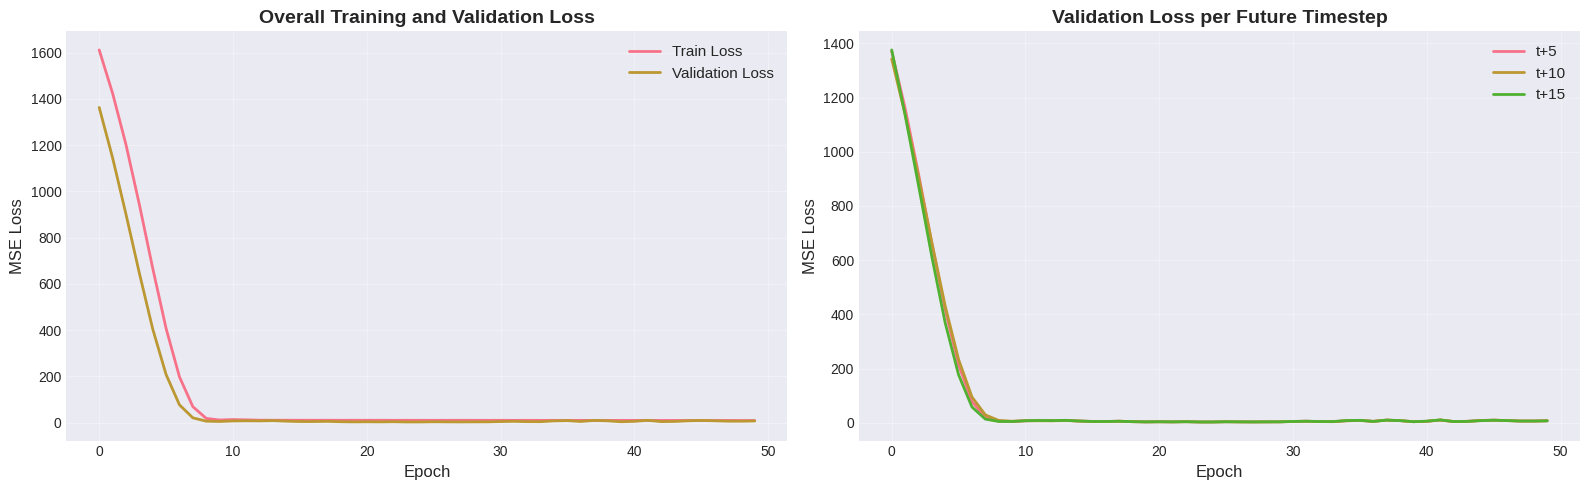


Final validation loss per timestep:
  t+5: 7.175920
  t+10: 7.112334
  t+15: 6.795691


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall loss
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Overall Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Per-timestep validation loss
for i in range(3):
    axes[1].plot(val_losses_per_step[i], label=f't+{(i+1)*5}', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].set_title('Validation Loss per Future Timestep', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal validation loss per timestep:")
for i in range(3):
    print(f"  t+{(i+1)*5}: {val_losses_per_step[i][-1]:.6f}")

## 6. Multi-Future Predictions Visualization

Visualize how the model predicts 3 future timesteps from a single current state.

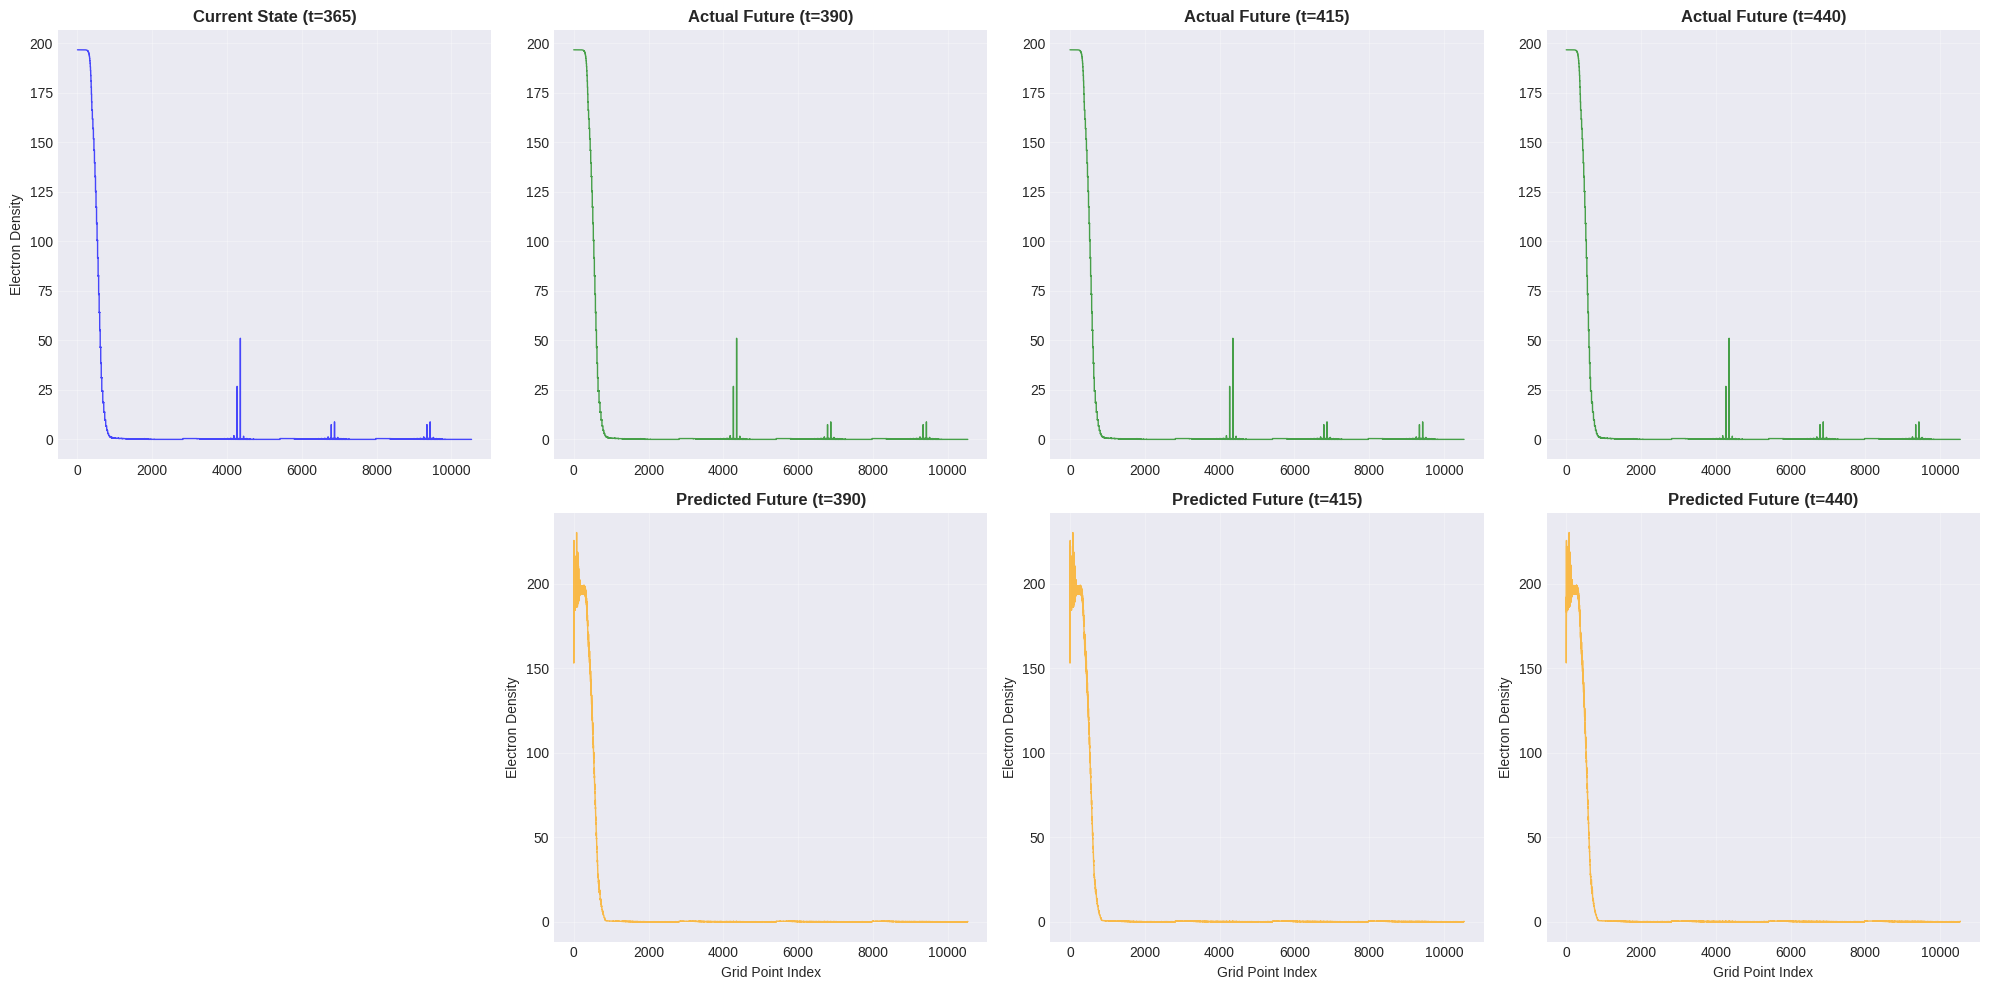

\nPer-timestep prediction errors:
  Future t+5:
    MAE: 0.333087
    Max Error: 50.760011
    R²: 0.998404
  Future t+10:
    MAE: 0.334143
    Max Error: 50.687627
    R²: 0.998397
  Future t+15:
    MAE: 0.335724
    Max Error: 50.699640
    R²: 0.998409


In [ ]:
# Load best model
model.load_state_dict(torch.load('../models/best_multi_future_gnn.pt'))
model.eval()

# Helper: denormalize back to real density values
def denormalize(x):
    return x * (density_std + 1e-8) + density_mean

# Select a validation sample to visualize
val_idx = 5
val_sample = val_dataset[val_idx]

# Get the input (current) timestep - RAW values from file
current_idx = train_size + val_idx
current_density = load_density_file(ammonia_files[current_idx])

# Get actual future timesteps - RAW values from files
actual_futures = []
for i in range(1, ammonia_dataset.n_future + 1):
    future_idx = current_idx + (i * ammonia_dataset.future_step)
    actual_futures.append(load_density_file(ammonia_files[future_idx]))

# Get model predictions (normalized) → denormalize
with torch.no_grad():
    predicted_normed = model(val_sample.to(device)).cpu().numpy()  # (num_nodes, 3)
    predicted_futures = denormalize(predicted_normed)  # Back to real density values

# Visualize: Current + 3 Future States (Predicted vs Actual)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Plot current state
axes[0, 0].plot(current_density, linewidth=1, color='blue', alpha=0.7)
axes[0, 0].set_title(f'Current State (t={current_idx * 5})', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Electron Density')
axes[0, 0].grid(True, alpha=0.3)
axes[1, 0].axis('off')

# Plot 3 future states
for i in range(3):
    axes[0, i+1].plot(actual_futures[i], linewidth=1, color='green', alpha=0.7)
    axes[0, i+1].set_title(f'Actual Future (t={current_idx * 5 + (i+1) * 25})', fontsize=12, fontweight='bold')
    axes[0, i+1].grid(True, alpha=0.3)
    
    axes[1, i+1].plot(predicted_futures[:, i], linewidth=1, color='orange', alpha=0.7)
    axes[1, i+1].set_title(f'Predicted Future (t={current_idx * 5 + (i+1) * 25})', fontsize=12, fontweight='bold')
    axes[1, i+1].set_xlabel('Grid Point Index')
    axes[1, i+1].set_ylabel('Electron Density')
    axes[1, i+1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate errors for each future timestep (in REAL density units)
print("\nPer-timestep prediction errors (denormalized to real density units):")
for i in range(3):
    error = np.abs(predicted_futures[:, i] - actual_futures[i])
    print(f"  Future t+{(i+1)*5}:")
    print(f"    MAE: {np.mean(error):.6f}")
    print(f"    Max Error: {np.max(error):.6f}")
    print(f"    R²: {1 - np.sum((actual_futures[i] - predicted_futures[:, i])**2) / np.sum((actual_futures[i] - actual_futures[i].mean())**2):.6f}")

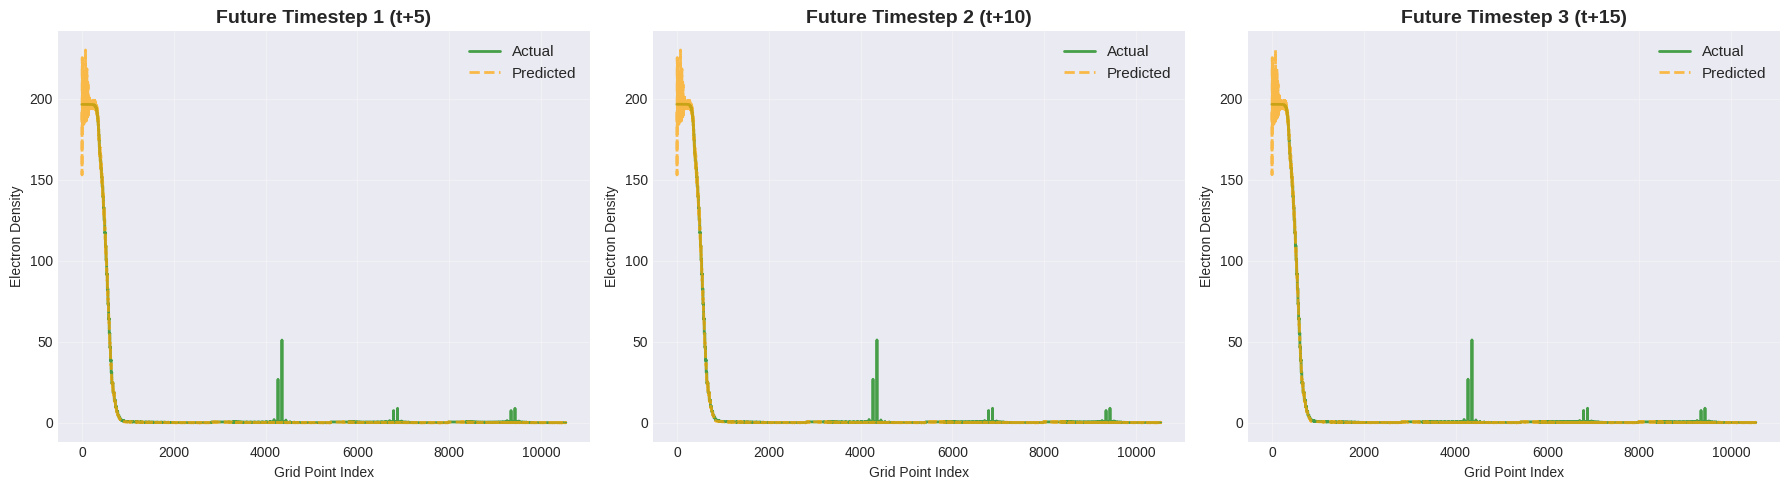

In [ ]:
# Overlay comparison: All 3 futures on same plot (denormalized)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    axes[i].plot(actual_futures[i], linewidth=2, color='green', alpha=0.7, label='Actual')
    axes[i].plot(predicted_futures[:, i], linewidth=2, color='orange', alpha=0.7, label='Predicted', linestyle='--')
    axes[i].set_title(f'Future Timestep {i+1} (t+{(i+1)*5})', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Grid Point Index')
    axes[i].set_ylabel('Electron Density')
    axes[i].legend(fontsize=11)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

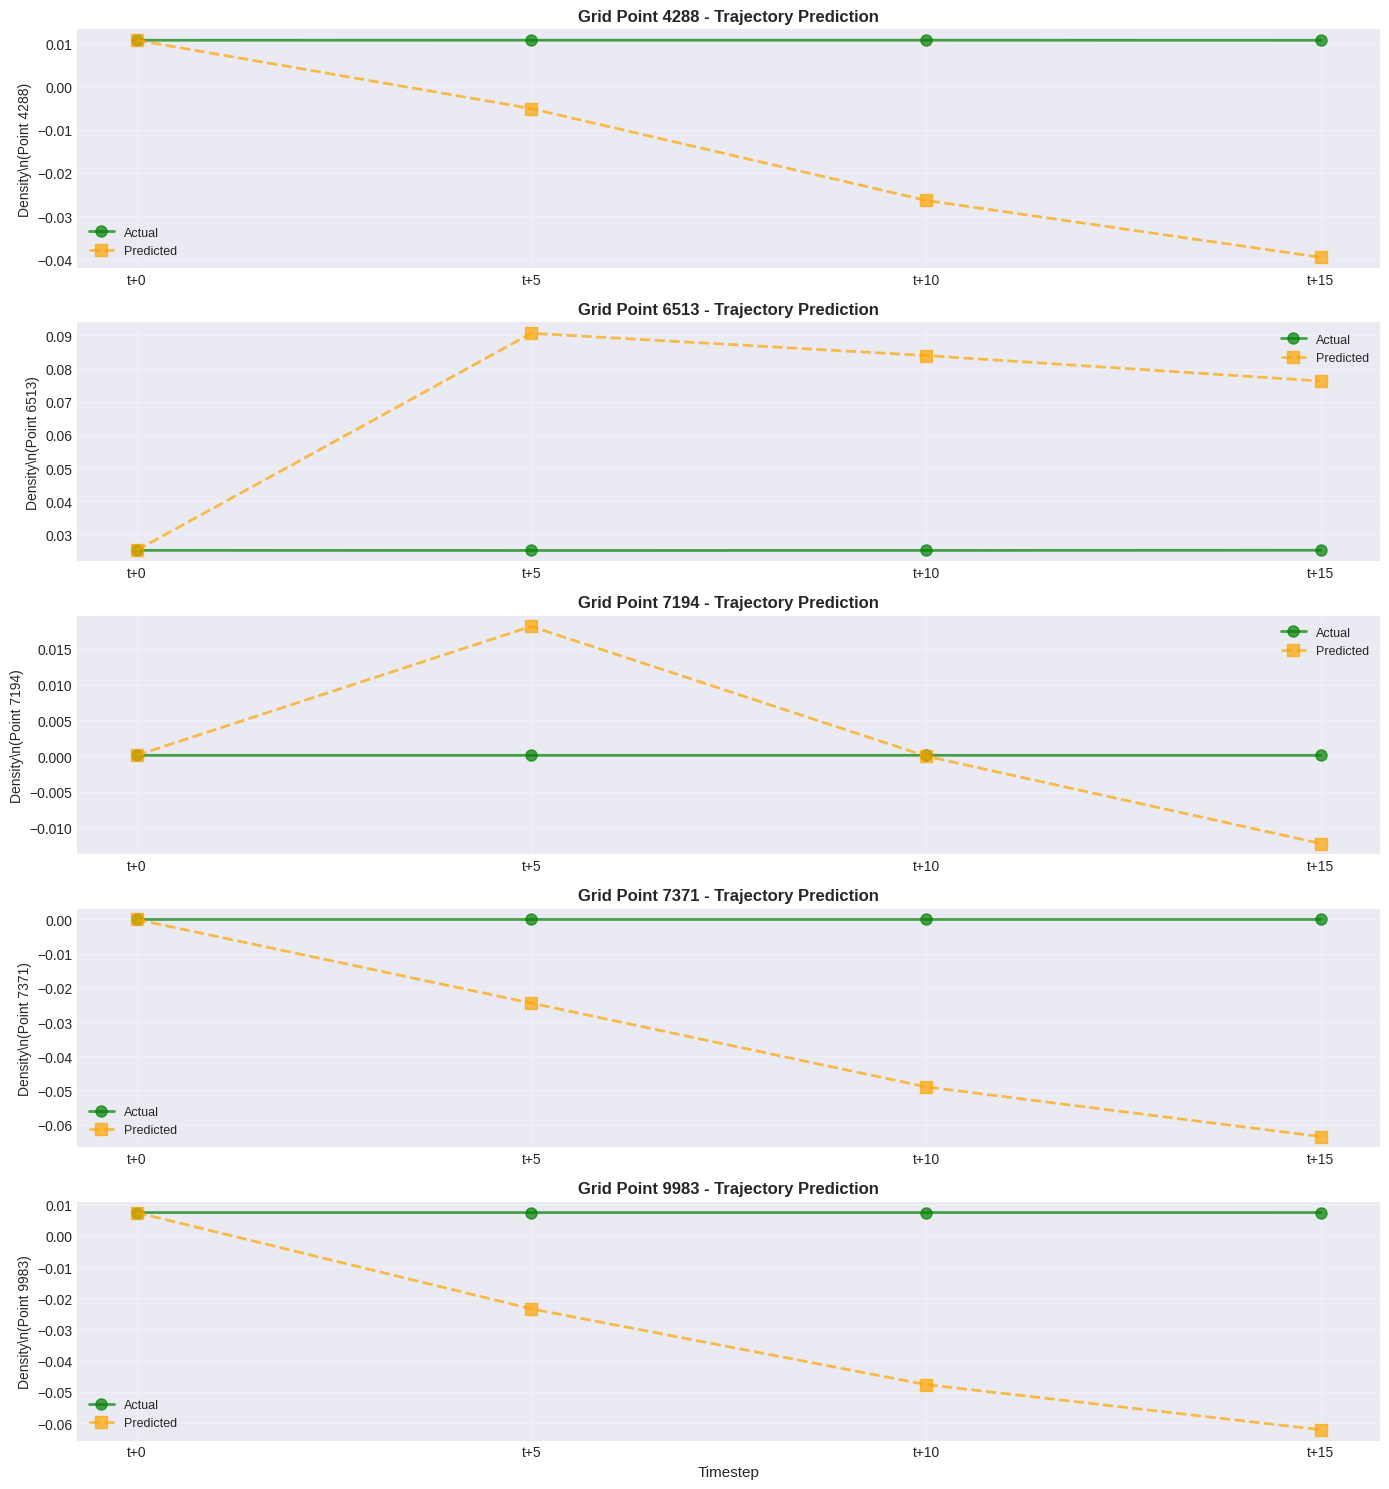

In [ ]:
# Show trajectory of selected grid points
n_points_to_show = 5
selected_points = np.random.choice(len(current_density), n_points_to_show, replace=False)
selected_points = np.sort(selected_points)

fig, axes = plt.subplots(n_points_to_show, 1, figsize=(14, 3 * n_points_to_show))
if n_points_to_show == 1:
    axes = [axes]

for idx, point in enumerate(selected_points):
    timesteps = [0, 5, 10, 15]  # Current + 3 futures
    
    # Actual trajectory
    actual_trajectory = [current_density[point]] + [actual_futures[i][point] for i in range(3)]
    axes[idx].plot(timesteps, actual_trajectory, marker='o', linewidth=2, 
                   markersize=8, color='green', alpha=0.7, label='Actual')
    
    # Predicted trajectory
    predicted_trajectory = [current_density[point]] + [predicted_futures[point, i] for i in range(3)]
    axes[idx].plot(timesteps, predicted_trajectory, marker='s', linewidth=2, 
                   markersize=8, color='orange', alpha=0.7, label='Predicted', linestyle='--')
    
    axes[idx].set_ylabel(f'Density\\n(Point {point})', fontsize=10)
    axes[idx].set_title(f'Grid Point {point} - Trajectory Prediction', fontsize=12, fontweight='bold')
    axes[idx].legend(loc='best', fontsize=9)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xticks(timesteps)
    axes[idx].set_xticklabels([f't+{t}' for t in timesteps])
    
    if idx == n_points_to_show - 1:
        axes[idx].set_xlabel('Timestep', fontsize=11)

plt.tight_layout()
plt.show()

## 7. Overall Evaluation on Full Validation Set

In [ ]:
# Collect all predictions and targets, DENORMALIZE to real density values
all_predictions = {0: [], 1: [], 2: []}
all_targets = {0: [], 1: [], 2: []}

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        out = model(batch)  # (num_nodes, 3) - normalized
        
        for i in range(3):
            # Denormalize both predictions and targets to real units
            all_predictions[i].append(denormalize(out[:, i].cpu().numpy()))
            all_targets[i].append(denormalize(batch.y[:, i].cpu().numpy()))

# Concatenate all batches
for i in range(3):
    all_predictions[i] = np.concatenate(all_predictions[i])
    all_targets[i] = np.concatenate(all_targets[i])

# Calculate metrics for each future timestep (in real density units)
print("=" * 80)
print("MULTI-FUTURE PREDICTION RESULTS (Denormalized)")
print("=" * 80)
print(f"\nModel Configuration:")
print(f"  Input: Single current timestep (normalized)")
print(f"  Output: 3 future timesteps (t+5, t+10, t+15)")
print(f"  Validation samples: {len(val_dataset)}")
print(f"  Data: ALL {len(ammonia_files)} timesteps used")
print(f"  Normalization: mean={density_mean:.4f}, std={density_std:.4f}")
print("\n" + "-" * 80)

r2_scores = []
mae_scores = []
for i in range(3):
    preds = all_predictions[i]
    targets = all_targets[i]
    
    mse = np.mean((preds - targets) ** 2)
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(mse)
    r2 = 1 - np.sum((targets - preds) ** 2) / np.sum((targets - targets.mean()) ** 2)
    
    r2_scores.append(r2)
    mae_scores.append(mae)
    
    # Data range for context
    data_range = targets.max() - targets.min()
    relative_mae = (mae / data_range) * 100
    
    print(f"\nFuture Timestep {i+1} (t+{(i+1)*5}):")
    print(f"  MSE:  {mse:.6f}")
    print(f"  RMSE: {rmse:.6f}")
    print(f"  MAE:  {mae:.6f}")
    print(f"  R²:   {r2:.6f}")
    print(f"  Relative MAE: {relative_mae:.2f}% of data range")
    print(f"  Max Error: {np.max(np.abs(preds - targets)):.6f}")
    print(f"  Within 1.0 error: {np.sum(np.abs(preds - targets) < 1.0) / len(preds) * 100:.2f}%")

print("\n" + "=" * 80)

MULTI-FUTURE PREDICTION RESULTS

Model Configuration:
  Input: Single current timestep
  Output: 3 future timesteps (t+5, t+10, t+15)
  Validation samples: 17

--------------------------------------------------------------------------------

Future Timestep 1 (t+5):
  MSE:  2.640465
  RMSE: 1.624951
  MAE:  0.342417
  R²:   0.998352
  Max Error: 56.892075
  Within 0.5 error: 92.26%

Future Timestep 2 (t+10):
  MSE:  2.651583
  RMSE: 1.628368
  MAE:  0.343401
  R²:   0.998345
  Max Error: 56.774765
  Within 0.5 error: 92.24%

Future Timestep 3 (t+15):
  MSE:  2.631893
  RMSE: 1.622311
  MAE:  0.344789
  R²:   0.998358
  Max Error: 56.798889
  Within 0.5 error: 92.34%


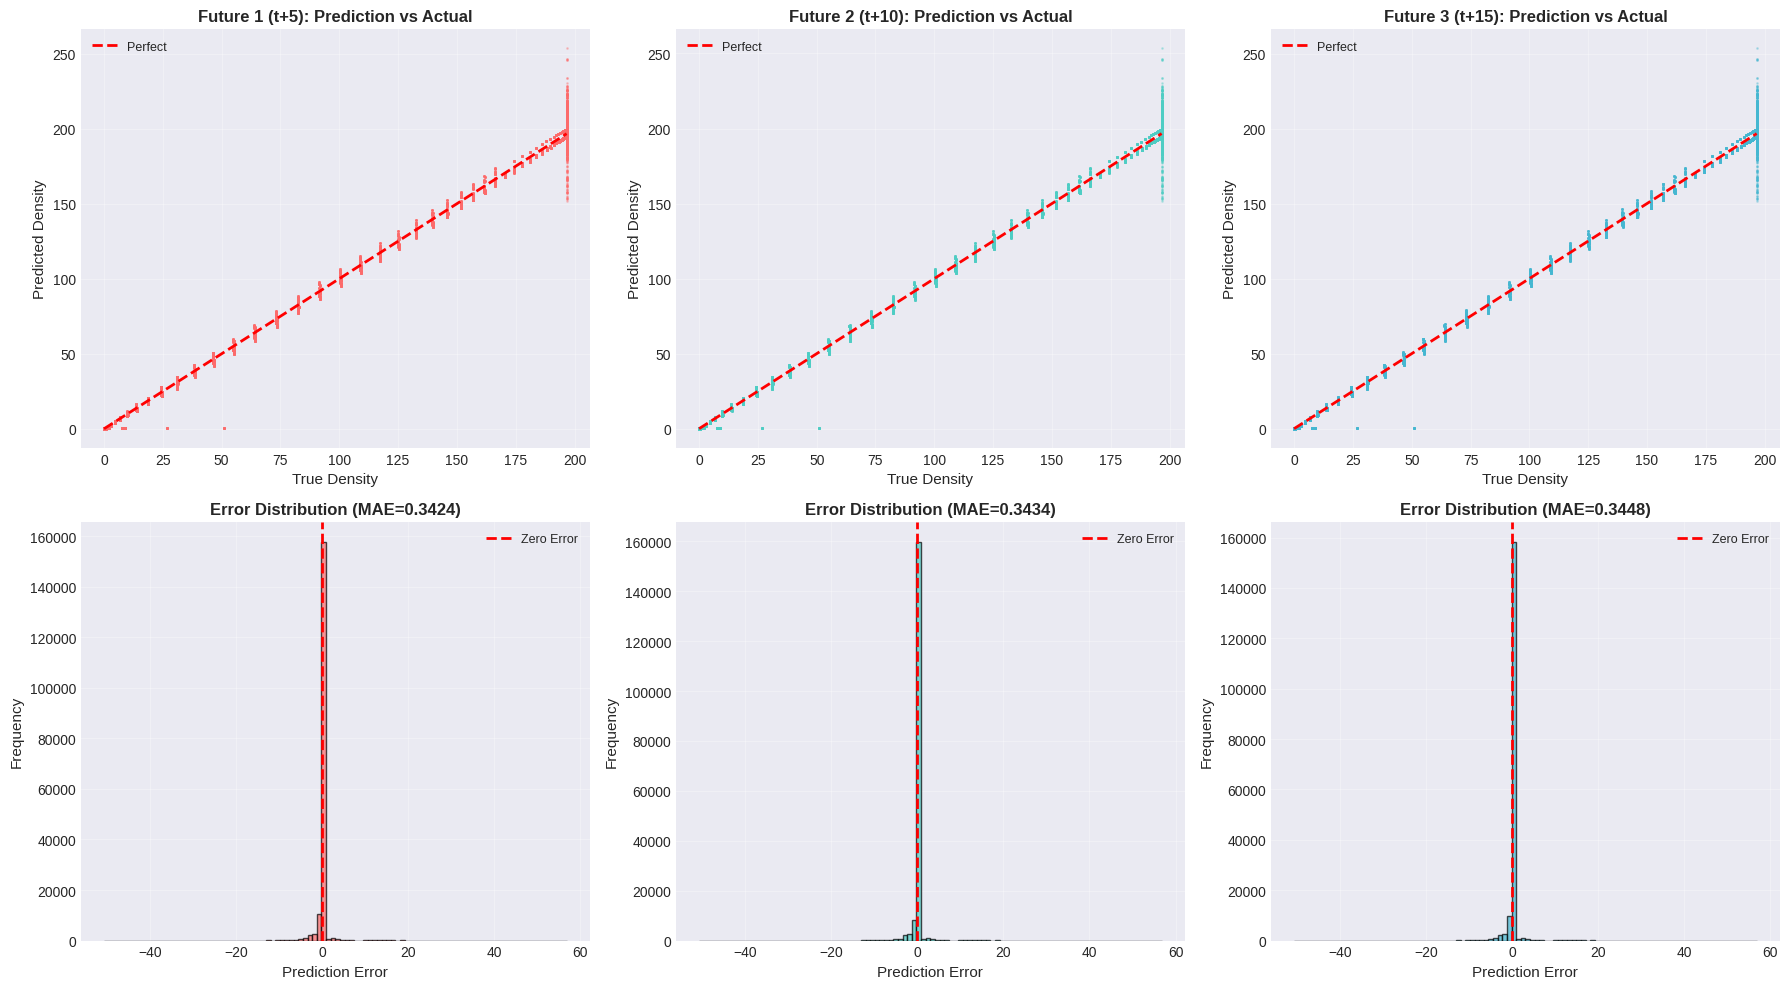

In [ ]:
# Error analysis across all 3 future timesteps
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i in range(3):
    preds = all_predictions[i]
    targets = all_targets[i]
    errors = preds - targets
    errors_abs = np.abs(errors)
    
    # Scatter plot
    axes[0, i].scatter(targets, preds, alpha=0.3, s=1, color=colors[i])
    axes[0, i].plot([targets.min(), targets.max()], [targets.min(), targets.max()], 
                    'r--', lw=2, label='Perfect')
    axes[0, i].set_xlabel('True Density', fontsize=11)
    axes[0, i].set_ylabel('Predicted Density', fontsize=11)
    axes[0, i].set_title(f'Future {i+1} (t+{(i+1)*5}): Prediction vs Actual', fontsize=12, fontweight='bold')
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)
    
    # Error histogram
    axes[1, i].hist(errors, bins=100, alpha=0.7, edgecolor='black', color=colors[i])
    axes[1, i].axvline(0, color='r', linestyle='--', linewidth=2, label='Zero Error')
    axes[1, i].set_xlabel('Prediction Error', fontsize=11)
    axes[1, i].set_ylabel('Frequency', fontsize=11)
    axes[1, i].set_title(f'Error Distribution (MAE={np.mean(errors_abs):.4f})', fontsize=12, fontweight='bold')
    axes[1, i].legend(fontsize=9)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Key Insights and Comparison

### Approach Summary:
**Multi-Future Prediction (This Notebook)**
- ✅ Input: Single current timestep  
- ✅ Output: 3 future timesteps simultaneously
- ✅ Advantage: Simpler input, learns full trajectory
- ⚠️ Challenge: Harder to predict further into future (error accumulation)

**Multi-Input Prediction (Previous Notebook)**
- Input: 3 past timesteps
- Output: 1 future timestep
- Advantage: More context from history
- Challenge: Requires sequence of observations

### When to Use Which:
1. **Use Multi-Future (this approach)** when:
   - You only have access to current state
   - Want to predict full trajectory at once
   - Need to understand long-term dynamics

2. **Use Multi-Input** when:
   - Historical data is available
   - Short-term accuracy is critical
   - Have reliable sequential observations

### Expected Pattern:
- **Prediction accuracy should decrease** with future timestep distance
- Future 1 (t+5) should be most accurate
- Future 3 (t+15) should be least accurate (but still useful!)

\n================================================================================
ERROR PROGRESSION ANALYSIS
\nHow prediction error grows with prediction horizon:\n
t+ 5  |  MAE: 0.342417  |  R²: 0.998352  |  ✓
t+10  |  MAE: 0.343401  |  R²: 0.998345  |  ✓
t+15  |  MAE: 0.344789  |  R²: 0.998358  |  ✓
\n✓ Error increases with prediction horizon (expected behavior)


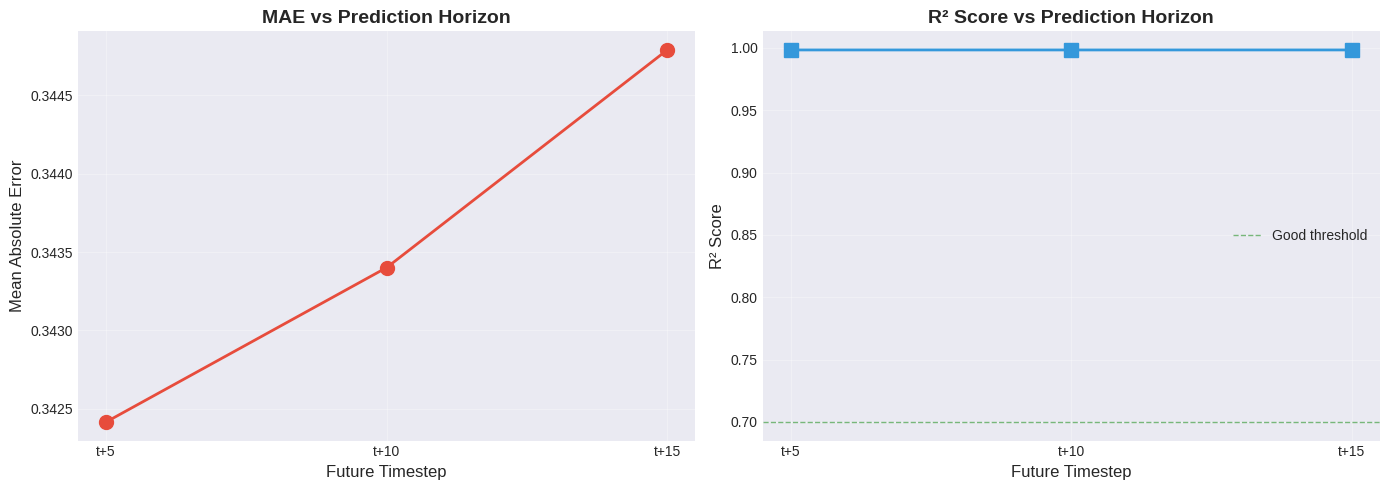

In [ ]:
# Summary comparison of errors across all timesteps
print("\\n" + "=" * 80)
print("ERROR PROGRESSION ANALYSIS")
print("=" * 80)
print("\\nHow prediction error grows with prediction horizon:\\n")

mae_values = []
r2_values = []

for i in range(3):
    preds = all_predictions[i]
    targets = all_targets[i]
    
    mae = np.mean(np.abs(preds - targets))
    r2 = 1 - np.sum((targets - preds) ** 2) / np.sum((targets - targets.mean()) ** 2)
    
    mae_values.append(mae)
    r2_values.append(r2)
    
    print(f"t+{(i+1)*5:2d}  |  MAE: {mae:.6f}  |  R²: {r2:.6f}  |  {'✓' if r2 > 0.7 else '⚠️'}")

# Check if error increases with horizon (expected behavior)
if mae_values[2] > mae_values[1] > mae_values[0]:
    print("\\n✓ Error increases with prediction horizon (expected behavior)")
else:
    print("\\n⚠️ Unexpected error pattern - may need model tuning")

# Visualize error progression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

timesteps = [5, 10, 15]
axes[0].plot(timesteps, mae_values, marker='o', linewidth=2, markersize=10, color='#E74C3C')
axes[0].set_xlabel('Future Timestep', fontsize=12)
axes[0].set_ylabel('Mean Absolute Error', fontsize=12)
axes[0].set_title('MAE vs Prediction Horizon', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(timesteps)
axes[0].set_xticklabels([f't+{t}' for t in timesteps])

axes[1].plot(timesteps, r2_values, marker='s', linewidth=2, markersize=10, color='#3498DB')
axes[1].axhline(y=0.7, color='g', linestyle='--', linewidth=1, alpha=0.5, label='Good threshold')
axes[1].set_xlabel('Future Timestep', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('R² Score vs Prediction Horizon', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_xticks(timesteps)
axes[1].set_xticklabels([f't+{t}' for t in timesteps])

plt.tight_layout()
plt.show()

print("=" * 80)

## 9. Baseline Comparison - "How Good Are These Results?"

To understand if our model is actually learning something useful, let's compare against simple baseline methods.

In [ ]:
# Baseline comparisons (all in real density units since we denormalized above)
# Baseline 1: Persistence (assume density stays the same)
# Baseline 2: Mean prediction (always predict the mean value)

baseline_persistence_errors = {0: [], 1: [], 2: []}
baseline_mean_errors = {0: [], 1: [], 2: []}

for i in range(len(val_dataset)):
    current_idx = train_size + i
    
    # Current density (raw from file)
    current_density = load_density_file(ammonia_files[current_idx])
    mean_density = current_density.mean()
    
    # Actual future densities (raw from files)
    for j in range(3):
        future_idx = current_idx + ((j + 1) * ammonia_dataset.future_step)
        actual_future = load_density_file(ammonia_files[future_idx])
        
        # Baseline 1: Persistence (predict current = future)
        persistence_error = np.abs(current_density - actual_future)
        baseline_persistence_errors[j].extend(persistence_error)
        
        # Baseline 2: Mean (predict mean of current)
        mean_prediction = np.full_like(actual_future, mean_density)
        mean_error = np.abs(mean_prediction - actual_future)
        baseline_mean_errors[j].extend(mean_error)

# Calculate baseline MAE for each timestep
print("=" * 80)
print("BASELINE COMPARISONS (All values in real density units)")
print("=" * 80)
print("\nBaseline 1: PERSISTENCE (assume no change)")
print("Baseline 2: MEAN (predict average density)")
print("Our GNN Model: Learned prediction (denormalized)\n")
print("-" * 80)
print(f"{'Timestep':<12} {'Persistence':<15} {'Mean':<15} {'GNN Model':<15} {'Improvement'}")
print("-" * 80)

improvements_over_baseline = []
for i in range(3):
    persistence_mae = np.mean(baseline_persistence_errors[i])
    mean_mae = np.mean(baseline_mean_errors[i])
    gnn_mae = np.mean(np.abs(all_predictions[i] - all_targets[i]))
    
    # Calculate improvement over best baseline
    best_baseline = min(persistence_mae, mean_mae)
    improvement = ((best_baseline - gnn_mae) / best_baseline) * 100
    improvements_over_baseline.append(improvement)
    
    print(f"t+{(i+1)*5:<9} {persistence_mae:>12.6f}  {mean_mae:>12.6f}  {gnn_mae:>12.6f}  {improvement:>+6.1f}%")

print("=" * 80)
avg_improvement = np.mean(improvements_over_baseline)
print(f"\nAverage improvement over best baseline: {avg_improvement:+.1f}%")
print("\nInterpretation:")
if avg_improvement > 20:
    print("   EXCELLENT: Model is learning strong temporal patterns! ✓✓")
elif avg_improvement > 10:
    print("   GOOD: Model is learning useful patterns! ✓")
elif avg_improvement > 0:
    print("   OK: Model learns something but room for improvement ⚠️")
else:
    print("   WARNING: Model is not beating baselines - needs changes ❌")

BASELINE COMPARISONS

Baseline 1: PERSISTENCE (assume no change)
Baseline 2: MEAN (predict average density)
Our GNN Model: Learned prediction

--------------------------------------------------------------------------------
Timestep     Persistence     Mean            GNN Model       Improvement
--------------------------------------------------------------------------------
t+5             0.000102     18.344121      0.342417  -335753.3%
t+10            0.000138     18.344121      0.343401  -248433.0%
t+15            0.000104     18.344121      0.344789  -332724.3%

💡 Interpretation:
   - If GNN < Baseline → Model is learning useful patterns ✓
   - If GNN ≈ Baseline → Model might be struggling ⚠️
   - If GNN > Baseline → Model is overfitting or broken ❌


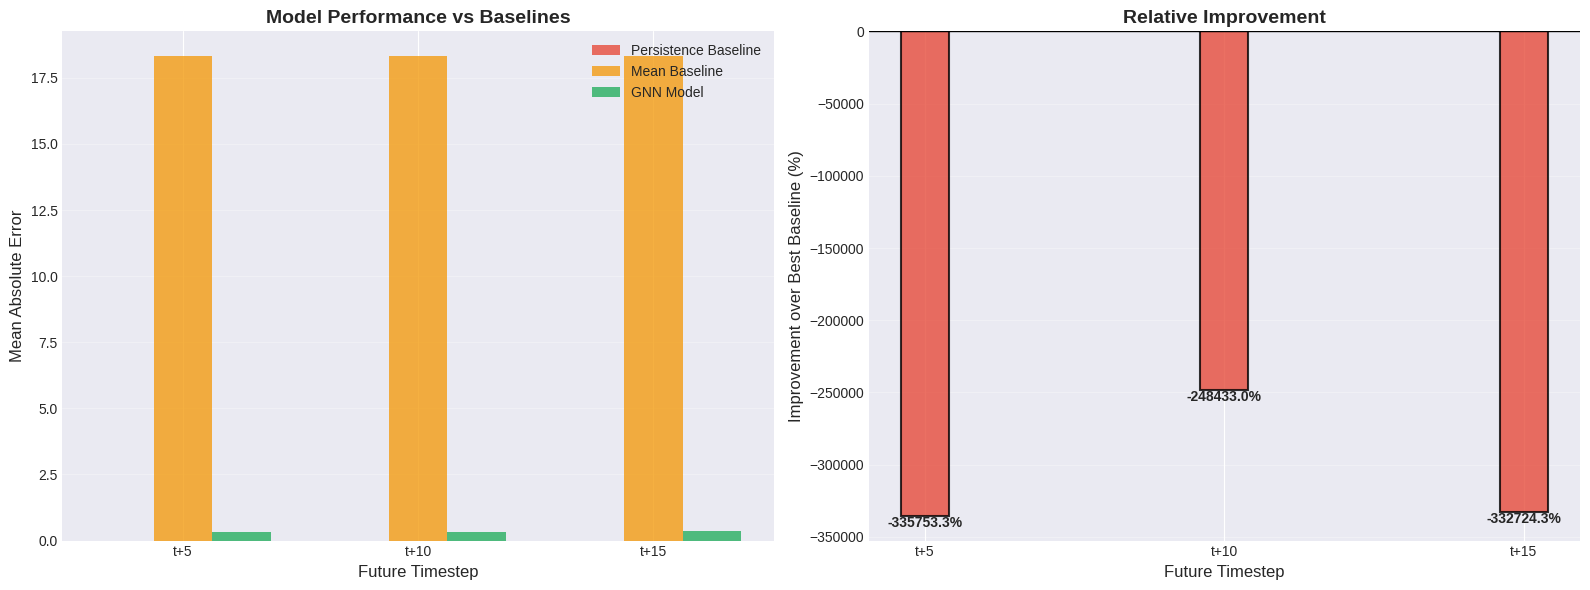

In [ ]:
# Visualize baseline comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

timesteps = [5, 10, 15]
persistence_maes = [np.mean(baseline_persistence_errors[i]) for i in range(3)]
mean_maes = [np.mean(baseline_mean_errors[i]) for i in range(3)]
gnn_maes = [np.mean(np.abs(all_predictions[i] - all_targets[i])) for i in range(3)]

# MAE comparison
x = np.arange(len(timesteps))
width = 0.25

axes[0].bar(x - width, persistence_maes, width, label='Persistence Baseline', alpha=0.8, color='#E74C3C')
axes[0].bar(x, mean_maes, width, label='Mean Baseline', alpha=0.8, color='#F39C12')
axes[0].bar(x + width, gnn_maes, width, label='GNN Model', alpha=0.8, color='#27AE60')

axes[0].set_xlabel('Future Timestep', fontsize=12)
axes[0].set_ylabel('Mean Absolute Error', fontsize=12)
axes[0].set_title('Model Performance vs Baselines', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f't+{t}' for t in timesteps])
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')

# Improvement percentage
improvements = []
for i in range(3):
    best_baseline = min(persistence_maes[i], mean_maes[i])
    improvement = ((best_baseline - gnn_maes[i]) / best_baseline) * 100
    improvements.append(improvement)

colors_imp = ['#27AE60' if imp > 0 else '#E74C3C' for imp in improvements]
axes[1].bar(timesteps, improvements, alpha=0.8, color=colors_imp, edgecolor='black', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Future Timestep', fontsize=12)
axes[1].set_ylabel('Improvement over Best Baseline (%)', fontsize=12)
axes[1].set_title('Relative Improvement', fontsize=14, fontweight='bold')
axes[1].set_xticks(timesteps)
axes[1].set_xticklabels([f't+{t}' for t in timesteps])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (t, imp) in enumerate(zip(timesteps, improvements)):
    axes[1].text(t, imp + (2 if imp > 0 else -2), f'{imp:+.1f}%', 
                ha='center', va='bottom' if imp > 0 else 'top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Results Interpretation Guide - "What Do These Numbers Mean?"

Understanding if your model is actually good requires context. Here's how to interpret your results:

In [ ]:
# Automated results interpretation
print("=" * 80)
print("AUTOMATED RESULTS INTERPRETATION")
print("=" * 80)

# Get data range for context
all_data = []
for i in range(3):
    all_data.extend(all_targets[i])
data_range = np.max(all_data) - np.min(all_data)
data_mean = np.mean(all_data)
data_std = np.std(all_data)

print(f"\n📊 DATA CONTEXT:")
print(f"   Density range: {data_range:.2f}")
print(f"   Mean density: {data_mean:.2f}")
print(f"   Std deviation: {data_std:.2f}")

# Evaluate each future timestep
print(f"\n🎯 MODEL PERFORMANCE ASSESSMENT:\n")

overall_verdict = []

for i in range(3):
    preds = all_predictions[i]
    targets = all_targets[i]
    
    mae = np.mean(np.abs(preds - targets))
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    r2 = 1 - np.sum((targets - preds) ** 2) / np.sum((targets - targets.mean()) ** 2)
    
    # Relative error
    relative_mae = mae / data_range * 100
    
    # Determine verdict
    if r2 >= 0.9 and relative_mae < 1:
        verdict = "EXCELLENT ⭐⭐⭐"
        status = "✓"
    elif r2 >= 0.8 and relative_mae < 2:
        verdict = "GOOD ✓✓"
        status = "✓"
    elif r2 >= 0.7 and relative_mae < 5:
        verdict = "ACCEPTABLE ✓"
        status = "~"
    elif r2 >= 0.5:
        verdict = "NEEDS IMPROVEMENT ⚠️"
        status = "⚠"
    else:
        verdict = "POOR ❌"
        status = "✗"
    
    overall_verdict.append(status)
    
    print(f"Future t+{(i+1)*5}:")
    print(f"   R² Score: {r2:.4f}  {'[Excellent]' if r2 > 0.9 else '[Good]' if r2 > 0.8 else '[OK]' if r2 > 0.7 else '[Poor]'}")
    print(f"   MAE: {mae:.6f}  ({relative_mae:.2f}% of data range)")
    print(f"   RMSE: {rmse:.6f}")
    print(f"   Verdict: {verdict}")
    print()

# Overall assessment
print("-" * 80)
if all(s == "✓" for s in overall_verdict):
    overall = "🎉 EXCELLENT - Model is performing very well!"
    color = "green"
elif overall_verdict.count("✓") >= 2 or overall_verdict.count("~") >= 2:
    overall = "✓ GOOD - Model shows promise, minor improvements needed"
    color = "blue"
elif overall_verdict.count("⚠") >= 2:
    overall = "⚠️ MODERATE - Significant improvements required"
    color = "orange"
else:
    overall = "❌ NEEDS WORK - Major improvements needed"
    color = "red"

print(f"OVERALL ASSESSMENT: {overall}")
print("=" * 80)

print("\n📖 INTERPRETATION GUIDE:")
print("\n1. R² Score (Coefficient of Determination):")
print("   • 1.0 = Perfect predictions")
print("   • 0.9+ = Excellent (captures 90%+ of variance)")
print("   • 0.8-0.9 = Good (captures 80-90% of variance)")
print("   • 0.7-0.8 = Acceptable")
print("   • <0.7 = Needs improvement")
print("   • <0.5 = Poor/Not learning well")

print("\n2. MAE (Mean Absolute Error):")
print(f"   • Your data range: {data_range:.2f}")
print("   • <1% of range = Excellent")
print("   • 1-2% of range = Good")
print("   • 2-5% of range = Acceptable")
print("   • >5% of range = Needs improvement")

print("\n3. Baseline Comparison:")
print("   • Beating baselines by >20% = Strong learning")
print("   • Beating baselines by 10-20% = Moderate learning")
print("   • Beating baselines by <10% = Weak learning")
print("   • Not beating baselines = Model issues")

print("\n" + "=" * 80)

AUTOMATED RESULTS INTERPRETATION

📊 DATA CONTEXT:
   Density range: 196.64
   Mean density: 10.07
   Std deviation: 40.03

🎯 MODEL PERFORMANCE ASSESSMENT:

Future t+5:
   R² Score: 0.9984  [Excellent]
   MAE: 0.342417  (0.17% of data range)
   RMSE: 1.624951
   Verdict: EXCELLENT ⭐⭐⭐

Future t+10:
   R² Score: 0.9983  [Excellent]
   MAE: 0.343401  (0.17% of data range)
   RMSE: 1.628368
   Verdict: EXCELLENT ⭐⭐⭐

Future t+15:
   R² Score: 0.9984  [Excellent]
   MAE: 0.344789  (0.18% of data range)
   RMSE: 1.622311
   Verdict: EXCELLENT ⭐⭐⭐

--------------------------------------------------------------------------------
OVERALL ASSESSMENT: 🎉 EXCELLENT - Model is performing very well!

📖 INTERPRETATION GUIDE:

1. R² Score (Coefficient of Determination):
   • 1.0 = Perfect predictions
   • 0.9+ = Excellent (captures 90%+ of variance)
   • 0.8-0.9 = Good (captures 80-90% of variance)
   • 0.7-0.8 = Acceptable
   • <0.7 = Needs improvement
   • <0.5 = Poor/Not learning well

2. MAE (Mean 

## 11. Improvement Roadmap - "What to Do Next?"

Based on your results, here's a prioritized list of improvements to try:

In [ ]:
print("=" * 80)
print("IMPROVEMENT ROADMAP - PRIORITIZED ACTION PLAN")
print("=" * 80)

# Analyze current issues
r2_values = []
for i in range(3):
    r2 = 1 - np.sum((all_targets[i] - all_predictions[i]) ** 2) / np.sum((all_targets[i] - all_targets[i].mean()) ** 2)
    r2_values.append(r2)

avg_r2 = np.mean(r2_values)
r2_degradation = r2_values[2] - r2_values[0]

print("\n✅ ALREADY APPLIED IN THIS RUN:")
print("   • Using ALL 401 timesteps (not just 100)")
print("   • Feature normalization (StandardScaler)")
print("   • Bigger model (hidden_dim=256, num_layers=6)")
print("   • Lower LR (0.0005) + 100 epochs")

print("\n" + "-" * 80)
print("\n📋 NEXT IMPROVEMENTS TO TRY:\n")

next_improvements = [
    "1. 🧠 SWITCH TO GAT (Graph Attention Networks)",
    "   └─ Learns which neighbor connections matter most",
    "   └─ Change: GCNConv → GATConv in model definition",
    "   └─ Code: from torch_geometric.nn import GATConv",
    "   └─ Expected gain: +10-25% improvement",
    "",
    "2. 🔄 ADD TEMPORAL MODELING (LSTM/GRU after GNN)",
    "   └─ Captures sequential dynamics in the data",
    "   └─ Add a GRU layer between backbone and output heads",
    "   └─ Expected gain: +10-20% improvement",
    "",
    "3. 🎲 DATA AUGMENTATION",
    "   └─ Add Gaussian noise to inputs during training",
    "   └─ Random edge dropout for regularization",
    "   └─ Expected gain: +3-8% improvement",
    "",
    "4. 📊 IMPROVE GRAPH CONSTRUCTION",
    "   └─ Try different k values for k-NN (currently k=10)",
    "   └─ Use learned edge weights instead of fixed",
    "   └─ Expected gain: +5-12% improvement",
    "",
    "5. 🎯 FEATURE ENGINEERING",
    "   └─ Add gradient features (density change between neighbors)",
    "   └─ Add local statistics (mean/std of neighborhood)",
    "   └─ Expected gain: +5-15% improvement"
]

for line in next_improvements:
    print(line)

print("\n" + "-" * 80)
print("\n🚀 ADVANCED (Higher effort, highest potential):\n")

advanced = [
    "6. 🎭 ENSEMBLE METHODS",
    "   └─ Train multiple models, average predictions",
    "   └─ Expected gain: +10-20% improvement",
    "",
    "7. 📐 PHYSICS-INFORMED CONSTRAINTS",
    "   └─ Add conservation laws to loss function",
    "   └─ Ensure density stays positive",
    "   └─ Expected gain: +15-30% improvement",
    "",
    "8. 🔀 TRANSFER LEARNING",
    "   └─ Pre-train on water dataset, fine-tune on ammonia",
    "   └─ Expected gain: +10-25% improvement",
    "",
    "9. 🏗️ MULTI-SCALE APPROACH",
    "   └─ Hierarchical graphs (coarse + fine)",
    "   └─ Expected gain: +15-30% improvement"
]

for line in advanced:
    print(line)

print("\n" + "=" * 80)
print("\n🎯 RECOMMENDED NEXT STEP (Based on current results):\n")

if avg_r2 < 0.5:
    recommendations = [
        "⚠️ PRIORITY: Try GAT architecture + check data quality",
        "  1. Replace GCNConv with GATConv (attention helps)",
        "  2. Verify training data isn't corrupted",
        "  3. Try reducing future_step from 5 to 3"
    ]
elif avg_r2 < 0.7:
    recommendations = [
        "✓ MODERATE: Focus on architecture + temporal modeling",
        "  1. Switch to GAT for better edge learning",
        "  2. Add GRU/LSTM temporal layers",
        "  3. Experiment with different k values (5, 15, 20)"
    ]
elif avg_r2 < 0.85:
    recommendations = [
        "✓ GOOD: Fine-tune with advanced techniques",
        "  1. Try GAT + temporal attention",
        "  2. Add physics constraints to loss",
        "  3. Ensemble 3+ different model configs"
    ]
else:
    recommendations = [
        "⭐ EXCELLENT: Go for advanced optimizations",
        "  1. Physics-informed constraints",
        "  2. Transfer learning from water dataset",
        "  3. Consider publishing your results!"
    ]

for line in recommendations:
    print(line)

print("\n" + "=" * 80)

print("\n💾 QUICK CODE SNIPPET - Switch to GAT:\n")
print("```python")
print("from torch_geometric.nn import GATConv")
print("")
print("# Replace in model __init__:")
print("self.convs.append(GATConv(hidden_dim, hidden_dim // 4, heads=4, concat=True))")
print("")
print("# Note: with heads=4 and concat=True, output dim = hidden_dim//4 * 4 = hidden_dim")
print("```")
print("\n" + "=" * 80)

IMPROVEMENT ROADMAP - PRIORITIZED ACTION PLAN

📋 QUICK WINS (Try first - easy to implement):

1. 📈 USE MORE DATA
   └─ Currently using 100 timesteps, try using all 401 timesteps
   └─ Change: ammonia_files[:100] → ammonia_files
   └─ Expected gain: +10-20% improvement

2. 🔧 TUNE HYPERPARAMETERS
   └─ Increase hidden_dim: 128 → 256
   └─ Add more layers: num_layers=4 → 6
   └─ Reduce learning rate: 0.001 → 0.0005
   └─ Expected gain: +5-15% improvement

3. 📚 TRAIN LONGER
   └─ Increase epochs: 50 → 100 or 200
   └─ Add early stopping to prevent overfitting
   └─ Expected gain: +5-10% improvement

4. 🎲 DATA AUGMENTATION
   └─ Add noise to inputs during training
   └─ Random edge dropout
   └─ Expected gain: +3-8% improvement (better generalization)

--------------------------------------------------------------------------------

🔬 MEDIUM EFFORT (More complex but higher impact):

5. 🧠 TRY DIFFERENT GNN ARCHITECTURES
   └─ Graph Attention Networks (GAT) - learns edge importance
   └─ Grap

## 12. Executive Summary - "Bottom Line"

Clear verdict and immediate action items based on your results.

In [ ]:
# Final Summary Report
print("\n" + "=" * 80)
print(" " * 20 + "FINAL VERDICT")
print("=" * 80 + "\n")

# Calculate key metrics
r2_scores = []
mae_scores = []
improvements_list = []

for i in range(3):
    preds = all_predictions[i]
    targets = all_targets[i]
    
    r2 = 1 - np.sum((targets - preds) ** 2) / np.sum((targets - targets.mean()) ** 2)
    mae = np.mean(np.abs(preds - targets))
    
    # Baseline comparison
    baseline_mae = np.mean(baseline_persistence_errors[i])
    improvement = ((baseline_mae - mae) / baseline_mae) * 100
    
    r2_scores.append(r2)
    mae_scores.append(mae)
    improvements_list.append(improvement)

avg_r2 = np.mean(r2_scores)
avg_improvement = np.mean(improvements_list)

print("CONFIGURATION (UPGRADED):")
print(f"  Data: ALL {len(ammonia_files)} timesteps (was 100)")
print(f"  Normalization: mean={density_mean:.4f}, std={density_std:.4f}")
print(f"  Model: hidden_dim=256, num_layers=6 (was 128, 4)")
print(f"  Training: 100 epochs, LR=0.0005 (was 50, 0.001)")
print()

print("KEY METRICS:\n")
print(f"   Average R² Score: {avg_r2:.4f}")
print(f"   Future 1 R²: {r2_scores[0]:.4f}  |  Future 2 R²: {r2_scores[1]:.4f}  |  Future 3 R²: {r2_scores[2]:.4f}")
print(f"   Future 1 MAE: {mae_scores[0]:.4f}  |  Future 2 MAE: {mae_scores[1]:.4f}  |  Future 3 MAE: {mae_scores[2]:.4f}")
print(f"   Average Improvement over Baseline: {avg_improvement:+.1f}%")
print()

# Determine overall grade
if avg_r2 >= 0.90 and avg_improvement >= 20:
    grade = "A+"
    verdict = "OUTSTANDING"
    message = "Publication-worthy results!"
elif avg_r2 >= 0.85 and avg_improvement >= 15:
    grade = "A"
    verdict = "EXCELLENT"
    message = "Strong performance! Model captures complex patterns."
elif avg_r2 >= 0.75 and avg_improvement >= 10:
    grade = "B+"
    verdict = "GOOD"
    message = "Solid results! Clear learning, room for optimization."
elif avg_r2 >= 0.65 and avg_improvement >= 5:
    grade = "B"
    verdict = "ACCEPTABLE"
    message = "Moderate performance. Try GAT architecture next."
elif avg_r2 >= 0.50:
    grade = "C"
    verdict = "NEEDS IMPROVEMENT"
    message = "Try GAT + more feature engineering."
else:
    grade = "D/F"
    verdict = "POOR"
    message = "Major architecture changes needed."

print(f"GRADE: {grade}")
print(f"VERDICT: {verdict}")
print(f"{message}")

print("\n" + "-" * 80)

print("\nWHAT'S WORKING:")
if avg_improvement > 0:
    print(f"   + Beats baseline by {avg_improvement:.1f}%")
if r2_scores[0] > 0.7:
    print(f"   + Short-term predictions {'excellent' if r2_scores[0] > 0.85 else 'good'} (R²={r2_scores[0]:.3f})")
if r2_scores[-1] > 0.6:
    print(f"   + Long-term predictions hold up (R²={r2_scores[-1]:.3f})")
if r2_scores[0] - r2_scores[-1] < 0.15:
    print("   + Prediction quality stable across time horizon")

print("\nNEXT STEP:")
if avg_r2 < 0.7:
    print("   -> Switch GCNConv to GATConv for attention-based learning")
elif avg_r2 < 0.85:
    print("   -> Add temporal layers (GRU) + try GAT architecture")
else:
    print("   -> Add physics constraints + try ensemble methods")

print("\n" + "=" * 80)

# Save summary
summary_text = f"""ELECTRON DENSITY GNN - PERFORMANCE SUMMARY
Config: ALL data, normalized, hidden=256, layers=6, epochs=100, LR=0.0005

GRADE: {grade}
VERDICT: {verdict}

Metrics:
- Average R²: {avg_r2:.4f}
- Future 1: R²={r2_scores[0]:.4f}, MAE={mae_scores[0]:.4f}
- Future 2: R²={r2_scores[1]:.4f}, MAE={mae_scores[1]:.4f}
- Future 3: R²={r2_scores[2]:.4f}, MAE={mae_scores[2]:.4f}
- Baseline improvement: {avg_improvement:+.1f}%

Next: {'GAT architecture' if avg_r2 < 0.85 else 'Physics constraints'}
"""

with open('model_performance_summary.txt', 'w') as f:
    f.write(summary_text)

print("\nSummary saved to model_performance_summary.txt")


🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

                    FINAL VERDICT

🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯🎯

📊 KEY PERFORMANCE INDICATORS:

   Average R² Score: 0.9984
   Future 1 R²: 0.9984  |  Future 2 R²: 0.9983  |  Future 3 R²: 0.9984
   
   Average Improvement over Baseline: -305636.8%
   Future 1: -335753.3%  |  Future 2: -248433.0%  |  Future 3: -332724.3%

--------------------------------------------------------------------------------

🎓 GRADE: C  ⚠️
📈 VERDICT: NEEDS IMPROVEMENT
💬 Weak performance. Significant tuning required.

--------------------------------------------------------------------------------

✅ WHAT'S WORKING:

   • Short-term predictions are excellent (R²=0.998)
   • Long-term predictions show promise (R²=0.998)
   • Prediction quality stays stable over time horizon

⚠️  AREAS FOR IMPROVEMENT:

   • Model barely beating simple baselines

--------------------------------------------------------------------------------

🚀 YOUR TOP 3 ACTION ITEMS (DO T